In [1]:
from pathlib import Path
import pandas as pd
import pyreadstat

In [2]:
data_path = Path("/Users/yizj/Desktop/AX-CPT/metaControl_behavioral_Inhibition/data/AXCPT_For_Server.sav")
print(data_path.exists())

True


In [3]:
df, meta = pyreadstat.read_sav(data_path)

In [4]:
print(df.shape)
print(df.columns.tolist())
df.head()

(316, 37)
['ID', 'Completed_AX_CPT_12yr', 'acc_rej_12yr', 'AX_CPT_Notes_12yr', 'Mean_RT_12yr', 'Std_pop_12yr', 'Std_3_12yr', 'Lo_Std_12yr', 'Hi_Std_12yr', 'AX_Count_12yr', 'AY_Count_12yr', 'BX_Count_12yr', 'BY_Count_12yr', 'AX_Count_Filtered_12yr', 'AY_Count_Filtered_12yr', 'BX_Count_Filtered_12yr', 'BY_Count_Filtered_12yr', 'Total_Filtered_12yr', 'AX_Acc_Count_12yr', 'AY_Acc_Count_12yr', 'BX_Acc_Count_12yr', 'BY_Acc_Count_12yr', 'AX_RT_12yr', 'AY_RT_12yr', 'BX_RT_12yr', 'BY_RT_12yr', 'AX_Acc_12yr', 'AY_Acc_12yr', 'BX_Acc_12yr', 'BY_Acc_12yr', 'PBSI_ErrorRate_12yr', 'PBSI_RT_12yr', 'PBSI_SUM_12yr', 'dprime_context_12yr', 'A_Cue_Bias_12yr', 'A_Cue_Bias_Check', 'AY_False_Alarm']


,ID,Completed_AX_CPT_12yr,acc_rej_12yr,AX_CPT_Notes_12yr,Mean_RT_12yr,Std_pop_12yr,Std_3_12yr,Lo_Std_12yr,Hi_Std_12yr,AX_Count_12yr,...,AY_Acc_12yr,BX_Acc_12yr,BY_Acc_12yr,PBSI_ErrorRate_12yr,PBSI_RT_12yr,PBSI_SUM_12yr,dprime_context_12yr,A_Cue_Bias_12yr,A_Cue_Bias_Check,AY_False_Alarm
0,6015.0,NaN,NaN,,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,6018.0,1.0,1.0,,450.33,127.57,382.71,67.62,833.04,105.0,...,0.357143,0.571429,0.928571,0.1875,0.174679,0.362179,0.498652,0.342373,0.342373,0.642857
2,6021.0,NaN,NaN,,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,6023.0,NaN,NaN,,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,6024.0,NaN,NaN,,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
print(meta.variable_value_labels)

{'acc_rej_12yr': {1.0: 'Keep', 9.0: 'Reject'}}


In [6]:
df.isna().sum().sort_values(ascending=False)

A_Cue_Bias_Check          181
dprime_context_12yr       180
PBSI_SUM_12yr             180
PBSI_RT_12yr              180
BX_RT_12yr                180
BY_RT_12yr                178
A_Cue_Bias_12yr           178
AY_RT_12yr                178
AX_Acc_Count_12yr         177
BY_Acc_Count_12yr         177
AX_RT_12yr                177
BX_Acc_12yr               177
AX_Acc_12yr               177
AY_Acc_12yr               177
AY_Acc_Count_12yr         177
BY_Acc_12yr               177
PBSI_ErrorRate_12yr       177
BX_Acc_Count_12yr         177
AY_False_Alarm            177
AX_Count_12yr             177
BY_Count_Filtered_12yr    177
BX_Count_Filtered_12yr    177
AY_Count_Filtered_12yr    177
AX_Count_Filtered_12yr    177
BY_Count_12yr             177
BX_Count_12yr             177
AY_Count_12yr             177
Total_Filtered_12yr       177
Hi_Std_12yr               177
Lo_Std_12yr               177
Std_3_12yr                177
Std_pop_12yr              177
Mean_RT_12yr              177
acc_rej_12

In [7]:
for col in df.columns:
    print(f"\n===== {col} =====")
    print(df[col].value_counts(dropna=False).head(20))


===== ID =====
ID
6015.0    1
6478.0    1
6499.0    1
6493.0    1
6490.0    1
6486.0    1
6484.0    1
6480.0    1
6479.0    1
6468.0    1
6503.0    1
6467.0    1
6465.0    1
6463.0    1
6455.0    1
6451.0    1
6450.0    1
6443.0    1
6502.0    1
6508.0    1
Name: count, dtype: int64

===== Completed_AX_CPT_12yr =====
Completed_AX_CPT_12yr
NaN    175
1.0    134
9.0      7
Name: count, dtype: int64

===== acc_rej_12yr =====
acc_rej_12yr
NaN    175
1.0    130
9.0     11
Name: count, dtype: int64

===== AX_CPT_Notes_12yr =====
AX_CPT_Notes_12yr
                                                                             300
Didn't complete whole task - confirmed                                         7
1 blk of 5 stop                                                                1
num lock issue                                                                 1
num lock error                                                                 1
many blocks of 5-6 for non-responses           

# Missingness
Check whether the participant-level AX-CPT summary file is suitable for:

- fitting at the participant summary level,
- estimating person-level latent parameters or derived cue/probe-level probabilities,
- comparing groups,
- performing descriptive QC.

Because the data are participant-level summaries rather than trial-level records, missingness affects not only sample size but also whether the latent quantities are interpretable.

In [8]:
id_col = "ID"
completion_col = "Completed_AX_CPT_12yr"
qc_col = "acc_rej_12yr"
notes_col = "AX_CPT_Notes_12yr"

count_cols = [
    "AX_Count_Filtered_12yr",
    "AY_Count_Filtered_12yr",
    "BX_Count_Filtered_12yr",
    "BY_Count_Filtered_12yr",
]

acc_count_cols = [
    "AX_Acc_Count_12yr",
    "AY_Acc_Count_12yr",
    "BX_Acc_Count_12yr",
    "BY_Acc_Count_12yr",
]

acc_rate_cols = [
    "AX_Acc_12yr",
    "AY_Acc_12yr",
    "BX_Acc_12yr",
    "BY_Acc_12yr",
]

rt_cols = [
    "AX_RT_12yr",
    "AY_RT_12yr",
    "BX_RT_12yr",
    "BY_RT_12yr",
]

derived_cols = [
    "PBSI_ErrorRate_12yr",
    "PBSI_RT_12yr",
    "PBSI_SUM_12yr",
    "dprime_context_12yr",
    "A_Cue_Bias_12yr",
    "A_Cue_Bias_Check",
    "AY_False_Alarm",
]

core_cols = count_cols + acc_count_cols

## Person-level missingness
A participant is not fully usable if one or more of the required count/correct-count fields are missing in a way that prevents reconstructing all four binomial cells.

Create indicators for:

- having all 4 filtered counts,
- having all 4 correct counts,
- having both,
- Keep vs Reject among those,
- any AX-CPT data at all.

In [9]:
df["has_all_4_counts"] = df[count_cols].notna().all(axis=1)
df["has_all_4_acc_counts"] = df[acc_count_cols].notna().all(axis=1)
df["model_usable_complete"] = df[core_cols].notna().all(axis=1)

# "Any AX-CPT data" = at least one of the core fields present
df["has_any_axcpt_core_data"] = df[core_cols].notna().any(axis=1)

In [10]:
person_level_summary = pd.Series({
    "total_rows": len(df),
    "n_with_any_axcpt_core_data": int(df["has_any_axcpt_core_data"].sum()),
    "n_with_all_4_counts": int(df["has_all_4_counts"].sum()),
    "n_with_all_4_acc_counts": int(df["has_all_4_acc_counts"].sum()),
    "n_model_usable_complete": int(df["model_usable_complete"].sum()),
    "n_missing_some_core_field": int((~df["model_usable_complete"]).sum()),
})

person_level_summary

total_rows                    316
n_with_any_axcpt_core_data    139
n_with_all_4_counts           139
n_with_all_4_acc_counts       139
n_model_usable_complete       139
n_missing_some_core_field     177
dtype: int64

In [11]:
print("QC flag counts (including missing):")
print(df[qc_col].value_counts(dropna=False).sort_index())

print("\nCompletion flag counts (including missing):")
print(df[completion_col].value_counts(dropna=False).sort_index())

QC flag counts (including missing):
acc_rej_12yr
1.0    130
9.0     11
NaN    175
Name: count, dtype: int64

Completion flag counts (including missing):
Completed_AX_CPT_12yr
1.0    134
9.0      7
NaN    175
Name: count, dtype: int64


In [12]:
print("Keep / Reject among complete model-usable cases:")
pd.crosstab(df[qc_col], df["model_usable_complete"], dropna=False)

Keep / Reject among complete model-usable cases:


model_usable_complete,False,True
acc_rej_12yr,,
1.0,0,130
9.0,2,9
NaN,175,0


In [19]:
print((usable[count_cols] == 0).sum())
print((usable[count_cols] < 5).sum())
print(usable[count_cols].describe())

AX_Count_Filtered_12yr    0
AY_Count_Filtered_12yr    1
BX_Count_Filtered_12yr    0
BY_Count_Filtered_12yr    0
dtype: int64
AX_Count_Filtered_12yr    0
AY_Count_Filtered_12yr    2
BX_Count_Filtered_12yr    2
BY_Count_Filtered_12yr    1
dtype: int64
       AX_Count_Filtered_12yr  AY_Count_Filtered_12yr  BX_Count_Filtered_12yr  \
count              139.000000              139.000000              139.000000   
mean                99.949640               13.971223               14.100719   
std                 12.226322                1.918417                2.214233   
min                 23.000000                0.000000                1.000000   
25%                102.000000               14.000000               14.000000   
50%                103.000000               14.000000               15.000000   
75%                104.000000               15.000000               15.000000   
max                105.000000               15.000000               15.000000   

       BY_Count_Filt

In [21]:
low_count_summary = pd.DataFrame({
    "zero_count": (usable[count_cols] == 0).sum(),
    "count_lt_5": (usable[count_cols] < 5).sum(),
    "count_lt_10": (usable[count_cols] < 10).sum()
})

low_count_summary.index = [label_map[c] for c in low_count_summary.index]
low_count_summary

,zero_count,count_lt_5,count_lt_10
AX,0,0,0
AY,1,2,3
BX,0,2,7
BY,0,1,3


## Identify the sparse participants

In [24]:
sparse_mask = (
    (usable["AX_Count_Filtered_12yr"] < 5) |
    (usable["AY_Count_Filtered_12yr"] < 5) |
    (usable["BX_Count_Filtered_12yr"] < 5) |
    (usable["BY_Count_Filtered_12yr"] < 5)
)

usable.loc[sparse_mask, [
    "ID", "acc_rej_12yr", "Completed_AX_CPT_12yr",
    "AX_Count_Filtered_12yr", "AY_Count_Filtered_12yr",
    "BX_Count_Filtered_12yr", "BY_Count_Filtered_12yr"
]]

,ID,acc_rej_12yr,Completed_AX_CPT_12yr,AX_Count_Filtered_12yr,AY_Count_Filtered_12yr,BX_Count_Filtered_12yr,BY_Count_Filtered_12yr
219,6513.0,9.0,1.0,24.0,5.0,2.0,8.0
229,6549.0,1.0,1.0,98.0,0.0,14.0,1.0
253,6641.0,9.0,9.0,23.0,4.0,1.0,6.0


In [26]:
usable.loc[sparse_mask, [
    "ID",
    "AX_Acc_12yr", "AY_Acc_12yr", "BX_Acc_12yr", "BY_Acc_12yr",
    "AX_RT_12yr", "AY_RT_12yr", "BX_RT_12yr", "BY_RT_12yr"
]]

,ID,AX_Acc_12yr,AY_Acc_12yr,BX_Acc_12yr,BY_Acc_12yr,AX_RT_12yr,AY_RT_12yr,BX_RT_12yr,BY_RT_12yr
219,6513.0,1.000000,0.8,0.0,0.75,593.17,977.75,NaN,607.00
229,6549.0,0.846939,0.0,0.0,0.00,753.63,NaN,NaN,NaN
253,6641.0,0.652174,0.5,1.0,0.50,551.67,1046.00,353.0,544.33


In [27]:
main_keep = usable[usable["acc_rej_12yr"] == 1].copy()

strict_fit = main_keep[
    (main_keep[count_cols] >= 5).all(axis=1)
].copy()

looser_fit = main_keep[
    (main_keep[count_cols] > 0).all(axis=1)
].copy()

print("Complete usable cases:", len(usable))
print("Keep only:", len(main_keep))
print("Keep + all counts > 0:", len(looser_fit))
print("Keep + all counts >= 5:", len(strict_fit))

Complete usable cases: 139
Keep only: 130
Keep + all counts > 0: 129
Keep + all counts >= 5: 129


In [29]:
fit_df = df[
    (df["acc_rej_12yr"] == 1) &
    (df[count_cols].notna().all(axis=1)) &
    ((df[count_cols] >= 5).all(axis=1)) &
    (df[acc_count_cols].notna().all(axis=1))
].copy()

print("Final fitting sample size:", len(fit_df))

Final fitting sample size: 129


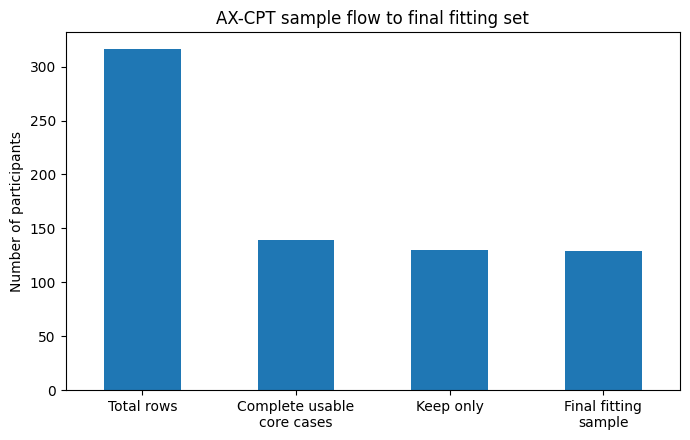

In [31]:
import matplotlib.pyplot as plt
import pandas as pd
flow_counts = pd.Series({
    "Total rows": 316,
    "Complete usable\ncore cases": 139,
    "Keep only": 130,
    "Final fitting\nsample": 129
})

plt.figure(figsize=(7, 4.5))
flow_counts.plot(kind="bar")
plt.ylabel("Number of participants")
plt.title("AX-CPT sample flow to final fitting set")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

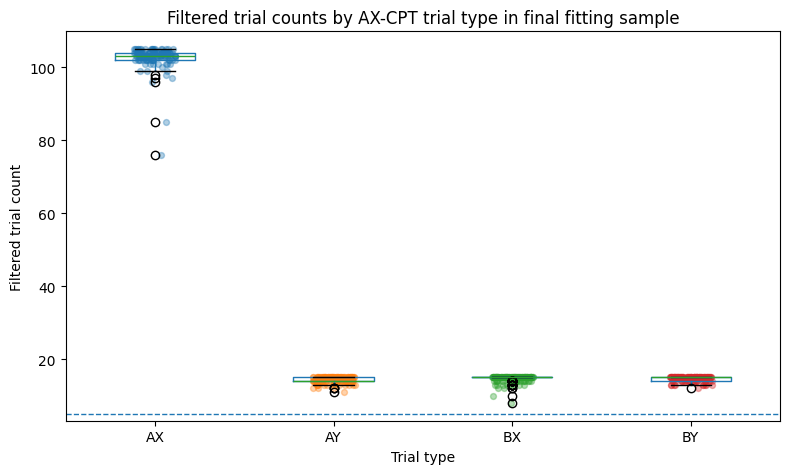

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

count_cols = [
    "AX_Count_Filtered_12yr",
    "AY_Count_Filtered_12yr",
    "BX_Count_Filtered_12yr",
    "BY_Count_Filtered_12yr"
]

label_map = {
    "AX_Count_Filtered_12yr": "AX",
    "AY_Count_Filtered_12yr": "AY",
    "BX_Count_Filtered_12yr": "BX",
    "BY_Count_Filtered_12yr": "BY"
}

long_counts = fit_df[count_cols].melt(
    var_name="trial_type",
    value_name="filtered_count"
)
long_counts["trial_type"] = long_counts["trial_type"].map(label_map)

fig, ax = plt.subplots(figsize=(8, 5))

long_counts.boxplot(column="filtered_count", by="trial_type", ax=ax, grid=False)

positions = {"AX": 1, "AY": 2, "BX": 3, "BY": 4}
rng = np.random.default_rng(42)

for trial, x in positions.items():
    y = long_counts.loc[long_counts["trial_type"] == trial, "filtered_count"].values
    jitter = rng.uniform(-0.12, 0.12, size=len(y))
    ax.scatter(np.full(len(y), x) + jitter, y, alpha=0.35, s=18)

ax.axhline(5, linestyle="--", linewidth=1)
ax.set_title("Filtered trial counts by AX-CPT trial type in final fitting sample")
ax.set_xlabel("Trial type")
ax.set_ylabel("Filtered trial count")
plt.suptitle("")
plt.tight_layout()
plt.show()

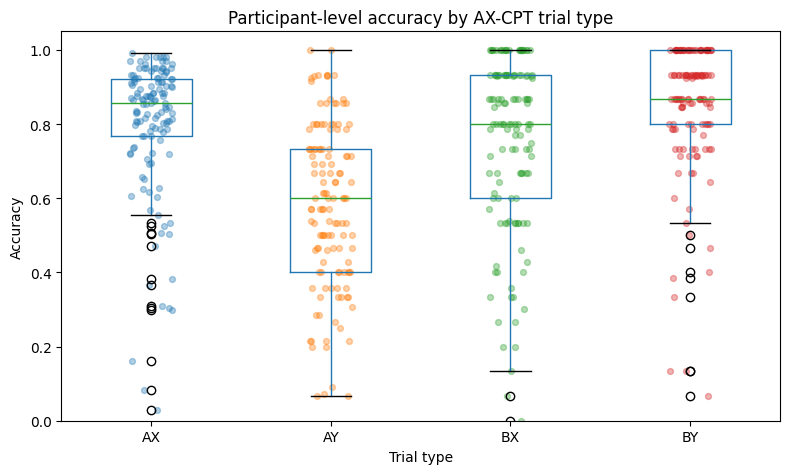

In [33]:
acc_rate_cols = [
    "AX_Acc_12yr",
    "AY_Acc_12yr",
    "BX_Acc_12yr",
    "BY_Acc_12yr"
]

acc_label_map = {
    "AX_Acc_12yr": "AX",
    "AY_Acc_12yr": "AY",
    "BX_Acc_12yr": "BX",
    "BY_Acc_12yr": "BY"
}

long_acc = fit_df[acc_rate_cols].melt(
    var_name="trial_type",
    value_name="accuracy"
)
long_acc["trial_type"] = long_acc["trial_type"].map(acc_label_map)

fig, ax = plt.subplots(figsize=(8, 5))

long_acc.boxplot(column="accuracy", by="trial_type", ax=ax, grid=False)

for trial, x in positions.items():
    y = long_acc.loc[long_acc["trial_type"] == trial, "accuracy"].values
    jitter = rng.uniform(-0.12, 0.12, size=len(y))
    ax.scatter(np.full(len(y), x) + jitter, y, alpha=0.35, s=18)

ax.set_ylim(0, 1.05)
ax.set_title("Participant-level accuracy by AX-CPT trial type")
ax.set_xlabel("Trial type")
ax.set_ylabel("Accuracy")
plt.suptitle("")
plt.tight_layout()
plt.show()

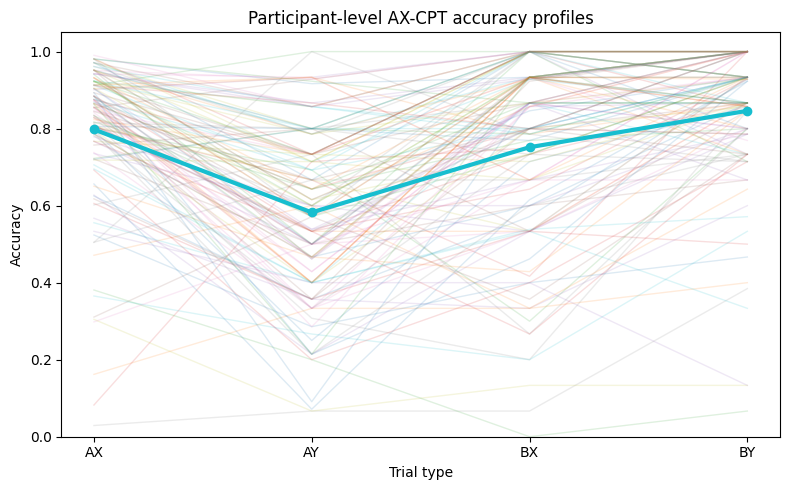

In [34]:
profile_cols = ["AX_Acc_12yr", "AY_Acc_12yr", "BX_Acc_12yr", "BY_Acc_12yr"]
profile_labels = ["AX", "AY", "BX", "BY"]

acc_matrix = fit_df[profile_cols].to_numpy()
mean_profile = np.nanmean(acc_matrix, axis=0)

fig, ax = plt.subplots(figsize=(8, 5))

for row in acc_matrix:
    ax.plot(profile_labels, row, alpha=0.15, linewidth=1)

ax.plot(profile_labels, mean_profile, linewidth=3, marker="o")

ax.set_ylim(0, 1.05)
ax.set_title("Participant-level AX-CPT accuracy profiles")
ax.set_xlabel("Trial type")
ax.set_ylabel("Accuracy")
plt.tight_layout()
plt.show()

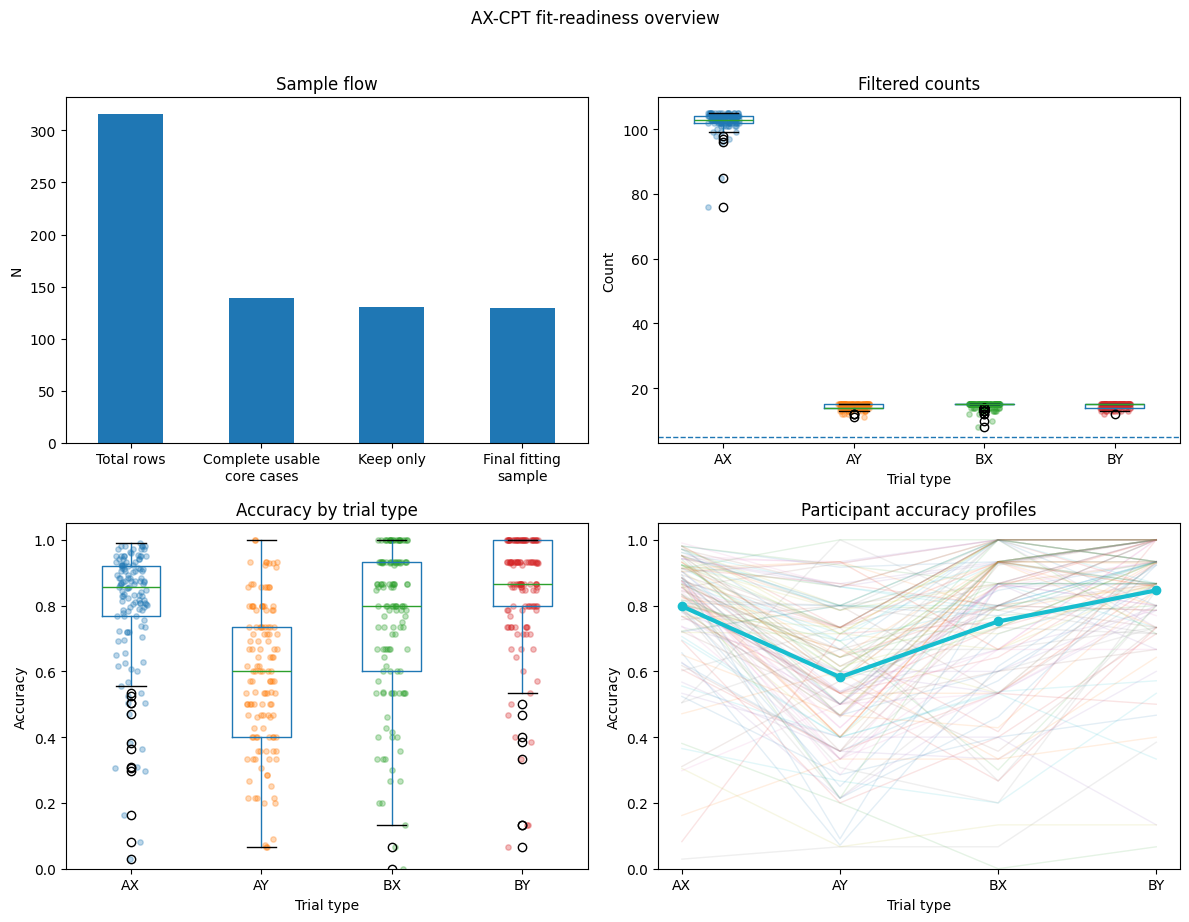

In [35]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# Panel 1: flow
flow_counts.plot(kind="bar", ax=axes[0, 0])
axes[0, 0].set_title("Sample flow")
axes[0, 0].set_ylabel("N")
axes[0, 0].tick_params(axis="x", rotation=0)

# Panel 2: counts
long_counts.boxplot(column="filtered_count", by="trial_type", ax=axes[0, 1], grid=False)
for trial, x in positions.items():
    y = long_counts.loc[long_counts["trial_type"] == trial, "filtered_count"].values
    jitter = rng.uniform(-0.12, 0.12, size=len(y))
    axes[0, 1].scatter(np.full(len(y), x) + jitter, y, alpha=0.3, s=15)
axes[0, 1].axhline(5, linestyle="--", linewidth=1)
axes[0, 1].set_title("Filtered counts")
axes[0, 1].set_xlabel("Trial type")
axes[0, 1].set_ylabel("Count")

# Panel 3: accuracies
long_acc.boxplot(column="accuracy", by="trial_type", ax=axes[1, 0], grid=False)
for trial, x in positions.items():
    y = long_acc.loc[long_acc["trial_type"] == trial, "accuracy"].values
    jitter = rng.uniform(-0.12, 0.12, size=len(y))
    axes[1, 0].scatter(np.full(len(y), x) + jitter, y, alpha=0.3, s=15)
axes[1, 0].set_ylim(0, 1.05)
axes[1, 0].set_title("Accuracy by trial type")
axes[1, 0].set_xlabel("Trial type")
axes[1, 0].set_ylabel("Accuracy")

# Panel 4: participant profiles
for row in acc_matrix:
    axes[1, 1].plot(profile_labels, row, alpha=0.12, linewidth=1)
axes[1, 1].plot(profile_labels, mean_profile, linewidth=3, marker="o")
axes[1, 1].set_ylim(0, 1.05)
axes[1, 1].set_title("Participant accuracy profiles")
axes[1, 1].set_xlabel("Trial type")
axes[1, 1].set_ylabel("Accuracy")

plt.suptitle("AX-CPT fit-readiness overview", y=1.02)
plt.tight_layout()
plt.show()

In [37]:
filtered_count_cols = [
    "AX_Count_Filtered_12yr",
    "AY_Count_Filtered_12yr",
    "BX_Count_Filtered_12yr",
    "BY_Count_Filtered_12yr"
]

filtered_totals = fit_df[filtered_count_cols].sum()
filtered_props = filtered_totals / filtered_totals.sum()

print("Filtered total counts across final fitting sample:")
print(filtered_totals)

print("\nFiltered proportions:")
print(filtered_props)

Filtered total counts across final fitting sample:
AX_Count_Filtered_12yr    13258.0
AY_Count_Filtered_12yr     1849.0
BX_Count_Filtered_12yr     1881.0
BY_Count_Filtered_12yr     1889.0
dtype: float64

Filtered proportions:
AX_Count_Filtered_12yr    0.702336
AY_Count_Filtered_12yr    0.097950
BX_Count_Filtered_12yr    0.099645
BY_Count_Filtered_12yr    0.100069
dtype: float64


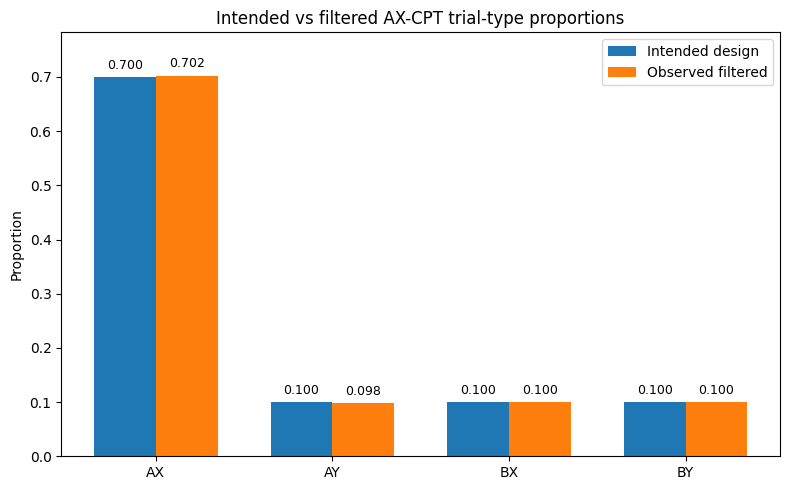

In [42]:
plot_df = comparison[["target_70_10_10_10", "observed_filtered"]]

x = np.arange(len(plot_df.index))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(x - width/2, plot_df["target_70_10_10_10"], width, label="Intended design")
ax.bar(x + width/2, plot_df["observed_filtered"], width, label="Observed filtered")

ax.set_xticks(x)
ax.set_xticklabels(plot_df.index)
ax.set_ylabel("Proportion")
ax.set_ylim(0, max(plot_df.max()) + 0.08)
ax.set_title("Intended vs filtered AX-CPT trial-type proportions")
ax.legend()

# annotate bars
for i, val in enumerate(plot_df["target_70_10_10_10"]):
    ax.text(i - width/2, val + 0.01, f"{val:.3f}", ha="center", va="bottom", fontsize=9)
for i, val in enumerate(plot_df["observed_filtered"]):
    ax.text(i + width/2, val + 0.01, f"{val:.3f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

In [43]:
export_path = Path("/Users/yizj/Desktop/AX-CPT/metaControl_behavioral_Inhibition/data/AXCPT_12yr_fitting_sample.csv")

fit_df.to_csv(export_path, index=False)

print("Saved filtered fitting dataset to:")
print(export_path)
print("\nShape:")
print(fit_df.shape)

Saved filtered fitting dataset to:
/Users/yizj/Desktop/AX-CPT/metaControl_behavioral_Inhibition/data/AXCPT_12yr_fitting_sample.csv

Shape:
(129, 41)
